In [278]:
import mne
import os
import numpy as np
import pandas as pd
import scipy.io
from scipy.signal import butter, filtfilt, welch, windows
from scipy import signal
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
from keras_gcn import GraphConv
import scipy.io
from sklearn.metrics import accuracy_score
seed = 111;
np.random.seed(seed)
tf.random.set_seed(seed)

In [279]:
band = 'delta'
#delta: 0.1-4
#theta: 4-7
#alpha 8-12
cluster = 5

In [280]:
class SqueezeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.squeeze(inputs, axis=2)



### CSZ Test

In [281]:
corr_folder = 'E:/sayan_24/GNN_aniket/CSZ_corr_data_' + band + '_cluster_' + str(cluster) + '/'
PSD_folder = 'E:/sayan_24/GNN_aniket/CSZ_PSD_data_' + band + '_cluster_' + str(cluster) + '/'
Label_folder = 'E:/sayan_24/GNN_aniket/CSZ_Label_data_' + band + '_cluster_' + str(cluster) + '/'

case = 1 

corr_csz = scipy.io.loadmat(corr_folder + f'csz_corr_matrix{case}.mat')
corr_test = scipy.io.loadmat(corr_folder + f'test_corr_matrix{case}.mat')
corr_he = scipy.io.loadmat(corr_folder + f'he_corr_matrix{case}.mat')

PSD_csz = scipy.io.loadmat(PSD_folder + f'csz_PSD{case}.mat')
PSD_test = scipy.io.loadmat(PSD_folder + f'test_PSD{case}.mat')
PSD_he = scipy.io.loadmat(PSD_folder + f'he_PSD{case}.mat')

#print(type(PSD_csz))

label_csz = scipy.io.loadmat(Label_folder + f'csz_label{case}.mat')
label_test = scipy.io.loadmat(Label_folder + f'test_label{case}.mat')
label_he = scipy.io.loadmat(Label_folder + f'he_label{case}.mat')

#print(corr_csz)

corr_csz = corr_csz['csz_corr_mat']
corr_test = corr_test['corr_matrix']
corr_he = corr_he['he_corr_mat']

PSD_csz = PSD_csz['csz_PSD']
PSD_test = PSD_test['test_PSD']
PSD_he = PSD_he['he_PSD']

print(PSD_csz.shape, PSD_csz.dtype, type(PSD_csz))
print(PSD_he.shape, PSD_he.dtype, type(PSD_he))

label_csz = label_csz['csz_label']
label_test = label_test['test_label']
label_he = label_he['he_label']

corr_train = np.vstack((corr_csz, corr_he))
label_train = np.vstack((label_csz, label_he))
PSD_train = np.vstack((PSD_csz, PSD_he))

(2640, 9, 4) float64 <class 'numpy.ndarray'>
(3917, 9, 4) float64 <class 'numpy.ndarray'>


### Processing

In [282]:
Y = label_train
Y_test = label_test

E = corr_train
E_test = corr_test

X = PSD_train
X_test = PSD_test

print(Y.shape, E.shape, X.shape, Y_test.shape, E_test.shape, X_test.shape)
print(Y.dtype, E.dtype, X.dtype, Y_test.dtype, E_test.dtype, X_test.dtype)
print(X[0])
print("##################")
print(E[0])
print("##################")
print(Y[0])

(6557, 2) (6557, 9, 9) (6557, 9, 4) (120, 2) (120, 9, 9) (120, 9, 4)
int32 float64 float64 int32 float64 float64
[[0.73312305 0.70377044 0.64336613 0.60418138]
 [0.73059055 0.72514739 0.66338418 0.62341706]
 [0.73101921 0.72197571 0.6947303  0.63928005]
 [0.73061604 0.72498244 0.62636042 0.53187119]
 [0.72227372 0.72666047 0.67017311 0.60721197]
 [0.72446029 0.73103687 0.67754945 0.61826444]
 [0.72411313 0.69439833 0.62065212 0.62231966]
 [0.73055794 0.70859224 0.64860051 0.60888984]
 [0.72317583 0.70683168 0.64841343 0.59466216]]
##################
[[ 0.         -0.07444398  0.18763024  0.05167751 -0.06484482 -0.00191083
  -0.30459105 -0.2303156  -0.28727669]
 [-0.07444398  0.          0.58577249  0.60923418  0.67758943  0.69240116
   0.34702874  0.45343639  0.44531815]
 [ 0.18763024  0.58577249  0.          0.44153393  0.35622327  0.54160811
  -0.10307719  0.09015512  0.08585971]
 [ 0.05167751  0.60923418  0.44153393  0.          0.65636339  0.56320747
   0.3665184   0.49994124  0.56

In [283]:
num_nodes=9 # clusters
node_dim=4 # feature vectors
data_layer = tf.keras.layers.Input(shape=(num_nodes, node_dim))
edge_layer = tf.keras.layers.Input(shape=(num_nodes, num_nodes))
conv_layer = GraphConv(units=300, step_num=3,)([data_layer, edge_layer])
#conv_layer1 = GraphConv(units=500, step_num=3,)([data_layer, edge_layer])

conv_layer2 = GraphConv(units=1, step_num=3,)([conv_layer, edge_layer])
out1 = SqueezeLayer()(conv_layer2)
out2 = tf.keras.layers.Dense(50, 'tanh')(out1)
#out2 = tf.keras.layers.Dense(50, 'tanh')(out2)
out = tf.keras.layers.Dense(2, 'softmax')(out2)
model = tf.keras.Model([data_layer, edge_layer], out)

In [284]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=adam_optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [285]:
training_history = model.fit(
    [X, E],
    Y,
    epochs=50,
    shuffle=True,
    validation_data=([X_test,E_test], Y_test),
)

Epoch 1/50
205/205 [==============================] - 3s 5ms/step - loss: 0.6040 - accuracy: 0.6442 - val_loss: 0.4238 - val_accuracy: 1.0000
Epoch 2/50
205/205 [==============================] - 1s 4ms/step - loss: 0.0408 - accuracy: 0.9986 - val_loss: 0.0041 - val_accuracy: 1.0000
Epoch 3/50
205/205 [==============================] - 1s 4ms/step - loss: 0.0053 - accuracy: 0.9995 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 4/50
205/205 [==============================] - 1s 3ms/step - loss: 0.0024 - accuracy: 0.9995 - val_loss: 5.9289e-04 - val_accuracy: 1.0000
Epoch 5/50
205/205 [==============================] - 1s 3ms/step - loss: 0.0019 - accuracy: 0.9997 - val_loss: 2.4849e-04 - val_accuracy: 1.0000
Epoch 6/50
205/205 [==============================] - 1s 3ms/step - loss: 6.9359e-04 - accuracy: 0.9998 - val_loss: 7.9129e-04 - val_accuracy: 1.0000
Epoch 7/50
205/205 [==============================] - 1s 3ms/step - loss: 3.1058e-04 - accuracy: 1.0000 - val_loss: 1.8291e-04 - val

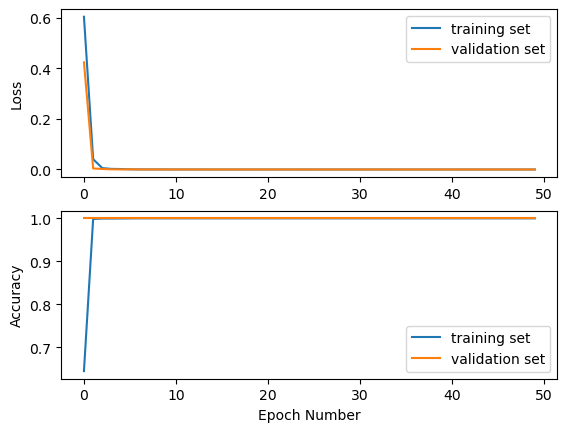

In [286]:
fig, axs = plt.subplots(2)

# Plot for loss
axs[0].set_ylabel('Loss')
axs[0].plot(training_history.history['loss'], label='training set')
axs[0].plot(training_history.history['val_loss'], label='validation set')
axs[0].legend()

# Plot for accuracy
axs[1].set_xlabel('Epoch Number')
axs[1].set_ylabel('Accuracy')
axs[1].plot(training_history.history['accuracy'], label='training set')
axs[1].plot(training_history.history['val_accuracy'], label='validation set')
axs[1].legend()

plt.show()

### Accuracy

In [287]:
Y_pred = model.predict([X_test, E_test])
#y_fit = [[1 if value > 0.5 else 0 for value in row] for row in Y_pred]
y_fit = (Y_pred == np.max(Y_pred, axis=1, keepdims=True)).astype(int)
accuracy = accuracy_score(Y_test, y_fit)
# print(Y_pred)
# print(y_fit)
print("Accuracy:", accuracy)

4/4 [==============================] - 0s 3ms/step
[[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]]
Accuracy: 1.0


### HEALTHY TEST

In [288]:
corr_folder = 'E:/sayan_24/GNN_aniket/HE_corr_data_' + band + '_cluster_' + str(cluster) + '/'
PSD_folder ='E:/sayan_24/GNN_aniket/HE_PSD_data_' + band + '_cluster_' + str(cluster) + '/'
Label_folder = 'E:/sayan_24/GNN_aniket/HE_Label_data_' + band + '_cluster_' + str(cluster) + '/'

case = 1

corr_csz = scipy.io.loadmat(corr_folder + f'csz_corr_matrix{case}.mat')
corr_test = scipy.io.loadmat(corr_folder + f'test_corr_matrix{case}.mat')
corr_he = scipy.io.loadmat(corr_folder + f'he_corr_matrix{case}.mat')

PSD_csz = scipy.io.loadmat(PSD_folder + f'csz_PSD{case}.mat')
PSD_test = scipy.io.loadmat(PSD_folder + f'test_PSD{case}.mat')
PSD_he = scipy.io.loadmat(PSD_folder + f'he_PSD{case}.mat')

#print(type(PSD_csz))

label_csz = scipy.io.loadmat(Label_folder + f'csz_label{case}.mat')
label_test = scipy.io.loadmat(Label_folder + f'test_label{case}.mat')
label_he = scipy.io.loadmat(Label_folder + f'he_label{case}.mat')

#print(corr_csz)

corr_csz = corr_csz['csz_corr_mat']
corr_test = corr_test['corr_matrix']
corr_he = corr_he['he_corr_mat']

PSD_csz = PSD_csz['csz_PSD']
PSD_test = PSD_test['test_PSD']
PSD_he = PSD_he['he_PSD']

print(PSD_csz.shape, PSD_csz.dtype, type(PSD_csz))
print(PSD_he.shape, PSD_he.dtype, type(PSD_he))

label_csz = label_csz['csz_label']
label_test = label_test['test_label']
label_he = label_he['he_label']

corr_train = np.vstack((corr_csz, corr_he))
label_train = np.vstack((label_csz, label_he))
PSD_train = np.vstack((PSD_csz, PSD_he))


(2245, 9, 4) float64 <class 'numpy.ndarray'>
(4680, 9, 4) float64 <class 'numpy.ndarray'>


### Processing

In [289]:
num_nodes=9 # clusters
node_dim=4 # feature vectors
data_layer = tf.keras.layers.Input(shape=(num_nodes, node_dim))
edge_layer = tf.keras.layers.Input(shape=(num_nodes, num_nodes))
conv_layer = GraphConv(units=300, step_num=3,)([data_layer, edge_layer])
#conv_layer1 = GraphConv(units=500, step_num=3,)([data_layer, edge_layer])

conv_layer2 = GraphConv(units=1, step_num=3,)([conv_layer, edge_layer])
out1 = SqueezeLayer()(conv_layer2)
out2 = tf.keras.layers.Dense(50, 'tanh')(out1)
#out2 = tf.keras.layers.Dense(50, 'tanh')(out2)
out = tf.keras.layers.Dense(2, 'softmax')(out2)
model = tf.keras.Model([data_layer, edge_layer], out)

In [290]:
Y = label_train
Y_test = label_test

E = corr_train
E_test = corr_test

X = PSD_train
X_test = PSD_test

print(Y.shape, E.shape, X.shape, Y_test.shape, E_test.shape, X_test.shape)
print(Y.dtype, E.dtype, X.dtype, Y_test.dtype, E_test.dtype, X_test.dtype)

(6925, 2) (6925, 9, 9) (6925, 9, 4) (120, 2) (120, 9, 9) (120, 9, 4)
int32 float64 float64 int32 float64 float64


In [291]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=adam_optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [292]:
training_history = model.fit(
    [X, E],
    Y,
    epochs=50,
    shuffle=True,
    validation_data=([X_test,E_test], Y_test),
)

Epoch 1/50
217/217 [==============================] - 3s 6ms/step - loss: 0.4451 - accuracy: 0.7883 - val_loss: 0.0380 - val_accuracy: 1.0000
Epoch 2/50
217/217 [==============================] - 1s 4ms/step - loss: 0.0176 - accuracy: 1.0000 - val_loss: 0.0029 - val_accuracy: 1.0000
Epoch 3/50
217/217 [==============================] - 1s 4ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 7.2049e-04 - val_accuracy: 1.0000
Epoch 4/50
217/217 [==============================] - 1s 4ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 6.7683e-04 - val_accuracy: 1.0000
Epoch 5/50
217/217 [==============================] - 1s 4ms/step - loss: 5.8621e-04 - accuracy: 1.0000 - val_loss: 3.1837e-04 - val_accuracy: 1.0000
Epoch 6/50
217/217 [==============================] - 1s 4ms/step - loss: 3.7456e-04 - accuracy: 1.0000 - val_loss: 2.3079e-04 - val_accuracy: 1.0000
Epoch 7/50
217/217 [==============================] - 1s 4ms/step - loss: 2.5797e-04 - accuracy: 1.0000 - val_loss: 1.5290e-

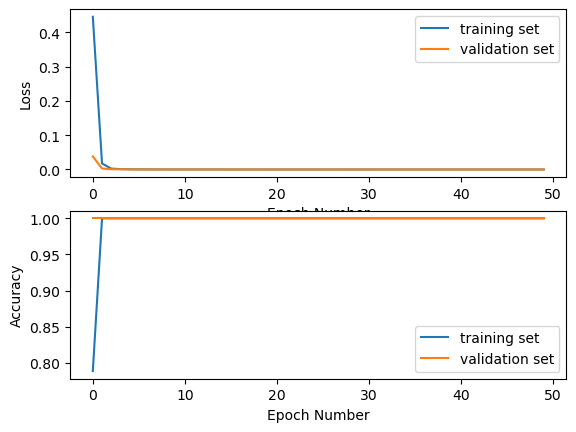

In [293]:
fig, axs = plt.subplots(2)

# Plot for loss
axs[0].set_xlabel('Epoch Number')
axs[0].set_ylabel('Loss')
axs[0].plot(training_history.history['loss'], label='training set')
axs[0].plot(training_history.history['val_loss'], label='validation set')
axs[0].legend()

# Plot for accuracy
axs[1].set_xlabel('Epoch Number')
axs[1].set_ylabel('Accuracy')
axs[1].plot(training_history.history['accuracy'], label='training set')
axs[1].plot(training_history.history['val_accuracy'], label='validation set')
axs[1].legend()

plt.show()

### Accuracy

In [294]:
Y_pred = model.predict([X_test, E_test])
#y_fit = [[1 if value > 0.5 else 0 for value in row] for row in Y_pred]
y_fit = (Y_pred == np.max(Y_pred, axis=1, keepdims=True)).astype(int)
accuracy = accuracy_score(Y_test, y_fit)
#print(Y_pred)
# print(y_fit)
print("Accuracy:", accuracy)

4/4 [==============================] - 0s 2ms/step
Accuracy: 1.0
